In [59]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [60]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [61]:
# lists everything we can interact with. dir() with no arguments
# will list everything that we have imported or defined in the current notebook. 
dir()

['Boston',
 'In',
 'MS',
 'Out',
 'VIF',
 'X',
 'Xma',
 '_',
 '_11',
 '_12',
 '_13',
 '_14',
 '_15',
 '_16',
 '_17',
 '_18',
 '_22',
 '_23',
 '_24',
 '_25',
 '_26',
 '_29',
 '_30',
 '_31',
 '_33',
 '_36',
 '_37',
 '_38',
 '_39',
 '_4',
 '_40',
 '_41',
 '_42',
 '_43',
 '_47',
 '_48',
 '_49',
 '_5',
 '_50',
 '_51',
 '_52',
 '_55',
 '_56',
 '_57',
 '_58',
 '_6',
 '_8',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i39',
 '_i4',
 '_i40',
 '_i41',
 '_i42',
 '_i43',
 '_i44',
 '_i45',
 '_i46',
 '_i47',
 '_i48',
 '_i49',
 '_i5',
 '_i50',
 '_i51',
 '_i52',
 '_i53',
 '_i54',
 '_i55',
 '_i56',
 '_i57',
 '_i

In [62]:
# importing the required dataset using the load_data method provided in the ISLP package. 
Boston=load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [63]:
Boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


In [64]:
# A Regression model has 4 main steps regardless of the dataset being used.

Step 1: Build the predictor matrix. 

In [65]:
# Boston.shape[0] counts the number of rows in the dataset. 
# np.ones is generating a list of 1's for each row in the dataset. For linear regression, we need an intercept constant(B0) that is part of the equation. To make sure the matrix multiplication is a success we need a variable to multiply B0 with. 
# By multiplying B0 with the 1's representing each row, it returns the exact same value. 

# lstat here grabs the column lower_status that represents proportion of residents in the neighbourhood classified as LOW INCOME. 
X=pd.DataFrame({ # represents a key value pair. 
    'intercept':np.ones(Boston.shape[0]),
    'lstat': Boston['lstat']})
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


Step 2: Instantiate the target

In [66]:
y=Boston['medv']

Step 3: Instantiate and fit the model

In [67]:
# sm.ols is specific to linear regression models, where OLS stands for Ordinary least squares which is the foundations for calculating the equation of a straigh line by minimizing the squared differences between data points and the line. 
# sm.ols defines model, does not fit it. 
model=sm.OLS(y, X)

# model.fit does the actual fitting. 
results=model.fit()

Step 4: Interpret the model

In [68]:
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


In [69]:
# fit method analyses the dataset and calculates statistical metrics like means, standard deviations etc. 
# transform modifies the dataset. It uses the values that were calculated during the fit step and transforms any additional data and the orignal dataset after new fit rules have been calculated. 
design=MS(['lstat'])
X=design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [70]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Tue, 07 Jul 2026   Prob (F-statistic):           5.08e-88
Time:                        15:32:18   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [71]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

In [72]:
# simulation of what would happen if you introduce new values to your dataset which were not included when the model was being trained. 
new_df=pd.DataFrame({'lstat':[5, 10, 15]})

# the model has already learnt the rules and calculated statistical metrics like std dev on the entire dataset, therefore we only call transform and not fit and transform
newX=design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [73]:
new_predictions=results.get_prediction(newX);
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [74]:
# confidence interval= estimates the uncertainity around the mean. 
new_predictions.conf_int(alpha=0.5)

array([[29.53006154, 30.07712669],
       [24.85435487, 25.25233981],
       [20.10675447, 20.49944667]])

In [75]:
# prediction inderval= estimates the uncertainity around a single data point in the future. 
new_predictions.conf_int(obs=True, alpha=0.5)

array([[25.59919254, 34.00799568],
       [20.85313657, 29.25355811],
       [16.10301435, 24.5031868 ]])

Defining functions

In [76]:
def abline(ax, b, m):

    # gets the min and max values on the x axis. 
    xlim=ax.get_xlim()

    # gets the min and max y values when the min/max values are inserted in the line equation. 
    ylim=[m*xlim[0]+b, m*xlim[1]+b]

    # draws the line connecting the boundary points. 
    ax.plot(xlim, ylim)

In [77]:
# *args takes any extra unnamed variables and packs them up in a single variable. 
# **kwargs takes named variables and packs them up to a single dictionary. 
def abline(ax, b, m, *args, **kwargs):
    xlim=ax.get_xlim()
    ylim=[m*xlim[0]+b, m*xlim[1]+b]
    ax.plot(xlim, ylim, *args, **kwargs)

/var/folders/0g/0rngkrh11rz7p3c55850pvjc0000gn/T/ipykernel_94039/4227944415.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[0],
/var/folders/0g/0rngkrh11rz7p3c55850pvjc0000gn/T/ipykernel_94039/4227944415.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[1],


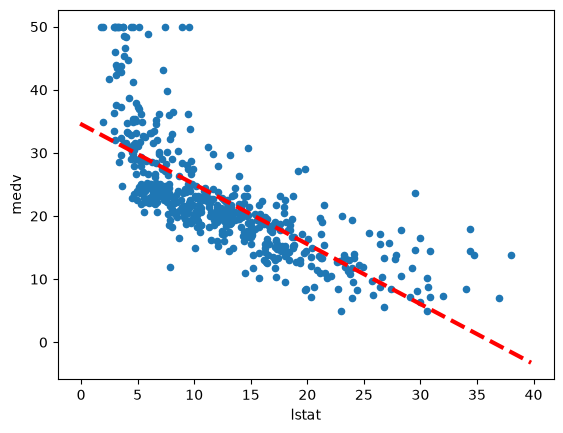

In [78]:
# ax is the background of the plot, the white empty box on which our line is visible. 
# We define that ax is a scatter plot with y and x axis with specific names .
ax=Boston.plot.scatter('lstat', 'medv')

# ab had three necessary arguments, ax, the intercept and the slope. 
abline(ax, 
       results.params[0], 
       results.params[1], 
       'r--', 
       linewidth=3)

Examining diagnostic plots

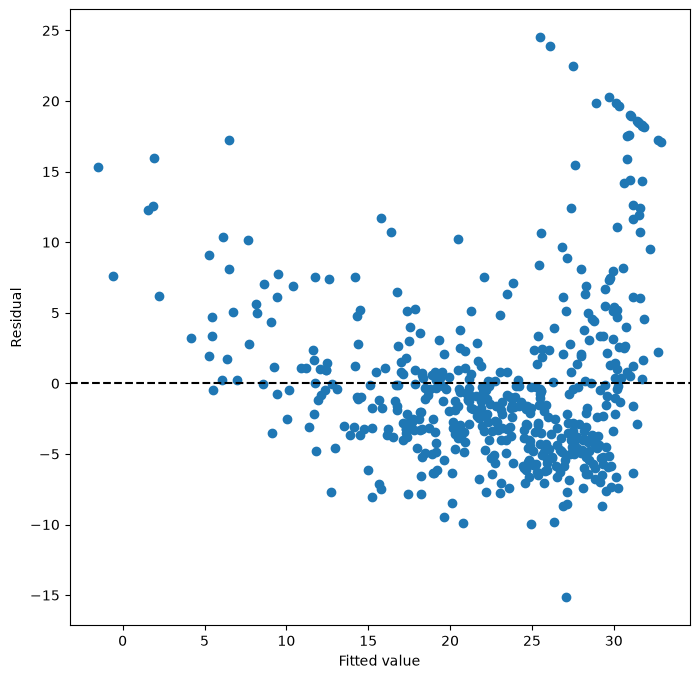

In [79]:
ax=subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

Checking for high leverage points. 

Text(0, 0.5, 'Leverage')

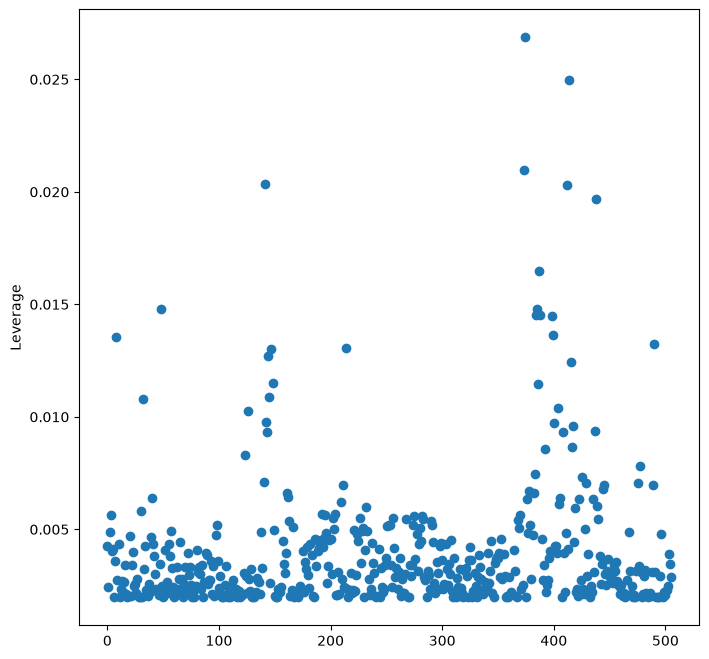

In [80]:
# the plot tells us which data points have high leverage, aka extreme X values. 
# a data point that sits closer to the x axis, does not have the power to pull the regression line towards it. points that are further away will distort the entire regression line. 
infl=results.get_influence()
ax=subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_label('Index')
ax.set_ylabel('Leverage')


In [81]:
# returned the index of the datapoint that has the highest leverage.
np.argmax(infl.hat_matrix_diag)

np.int64(374)

Multiple linear regression

In [82]:
# Uses 2 predictors, lstat and age, to find boston housing prices. 
# Since X contains a column of ones, statsmodels will correctly calculate the intercept 
# fit will make sure the predictors that we have chosen actuall exist. transform will drop all other columns that are not required. Will also add the column of ones for intercept calculation. 
X=MS(['lstat', 'age']).fit_transform(Boston)
model1=sm.OLS(y,X)

# this is when the model performs Ols to form a line that minimises RSS. 
results1=model1.fit()
summarize(results1)


,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


value interpretation: When lstat and age are both 0, the housing price is around 33.2. t value is 45, further away from indicating very significant. 
lstat coeff is -1.03, indicating a 1% increase in low income residents in a neighbourhood, the predicted home price drops by roughly $1.03. 
age coeff is positive, for an additional of 1 year of the house age, the predicted home price increases by 0.03 units
Std errors for both are relatively small

In [83]:
terms=Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

In [84]:
X=MS(terms).fit_transform(Boston)
model=sm.OLS(y,X)
results=model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


In [85]:
# Since age has a high p value, it indicates that the NULL HYPOTHESIS is TRUE. The predictor makes no impact on the outcome. it is better to get rid of such predictors from the dataset
minus_age=Boston.columns.drop(['medv', 'age'])
Xma=MS(minus_age).fit_transform(Boston)
model1=sm.OLS(y, Xma)
summarize(model1.fit())

,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


In [86]:
dir(results)

['HC0_se',
 'HC1_se',
 'HC2_se',
 'HC3_se',
 '_HCCM',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abat_diagonal',
 '_cache',
 '_data_attr',
 '_data_in_cache',
 '_get_robustcov_results',
 '_get_wald_nonlinear',
 '_is_nested',
 '_transform_predict_exog',
 '_use_t',
 '_wexog_singular_values',
 'aic',
 'bic',
 'bse',
 'centered_tss',
 'compare_f_test',
 'compare_lm_test',
 'compare_lr_test',
 'condition_number',
 'conf_int',
 'conf_int_el',
 'cov_HC0',
 'cov_HC1',
 'cov_HC2',
 'cov_HC3',
 'cov_kwds',
 'cov_params',
 'cov_type',
 'df_model',
 'df_resid',
 'diagn',
 'eigenvals',
 'el_test',
 'ess',
 'f_pval

In [87]:
# Varinace inflation factors measures how much variance of an estimated regression coeffecient is increased because of collinearity btw predictors.  
vals=[VIF(X, i)
      for i in range(1, X.shape[1])]
vif=pd.DataFrame({'vif':vals}, index=X.columns[1:])
vif
# vif=1, no collinearity btw this predictor and other predictors. 
# 1<vif<5, moderate correlation. 
# vif>5 high collinearity. 

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


Including interaction terms

Model Equation:
Price = 36.0885 - 1.3921(lstat) - 0.0007(age) + 0.0042(lstat * age)

In [88]:
X=MS(['lstat', 'age',('lstat', 'age')]).fit_transform(Boston)
model2=sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


Non linear transformations of the Predictors

In [ ]:
# rather than assuming a straight line for lsat, it creates 2 components, linear and quadratic. 
X=MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model3=sm.OLS(y, X)
results3=model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


17.7151 predicted house price when age is 0
-179.2279 represents a downward trend. As lstat increases, housing prices decrease dramatically. 
72.9908, is the quadratic component that tells you the shape of the curve. 



In [ ]:
# anova performs the hypothesis test comparing the 2 models. Null hypo being the bigger model is not needed and alternate being the bigger model is superior.
# since the f value is 177.27 for the quadratic model, it is evidence that the quadratic polynomial in lsat improves the model.  
anova_lm(results1, results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


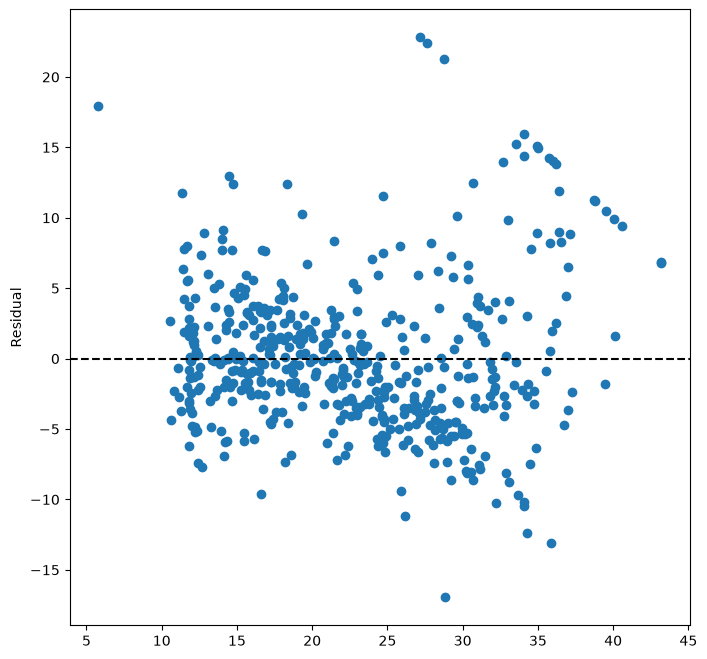

In [91]:
ax=subplots(figsize=(8,8))[1]
ax.scatter(results3.fittedvalues, results3.resid)
ax.set_label('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')